<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFFF; max-width: 90%; overflow-x: auto; color: #000000;">

<img src="resources/swdb_logo.jpg">


<h1 align="center">Workshop 2 Extended: Real Dynamic Routing Data</h1>
<h3 align="center">Summer Workshop on the Dynamic Brain</h3>
<h4 align="center">Thursday, August 27th, 2026</h4>
<h4 align="center">Day 4</h4>

---

***Authors:** Nick Steinmetz, Carrie Stine*

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## Applying the Analysis to Real Neural Recordings

In Workshop 2, we showed the pitfall in a simulation where we knew the ground truth.
Now we apply the same pipeline to a real session from the
**Dynamic Routing** dataset — where the neurons *might* encode things, and we
need the controls to tell us what is real.

### The Dynamic Routing task

Four stimulus types — vis1, vis2, sound1, sound2 — appear on every trial.
The session alternates between **visual** and **auditory context blocks**.
- Visual context: only vis1 triggers reward.
- Auditory context: only sound1 triggers reward.

The *same* stimulus can be a target or a non-target depending on context.
This context (visual vs auditory) alternates in blocks, just like the
+1/−1 blocks in our simulation.

### What we will test

1. **Test 1 (pupil analog):** Are neurons correlated with running speed?
   Running speed, like pupil diameter, has slow fluctuations.
2. **Test 2 (block decoding):** Can we decode the context block (vis vs aud)?

We will apply both the **naive analysis** and the **good controls** from Part 1.

</div>


# Part 1 - Real Data Setup

In [1]:
# standard imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import KFold




# Global figure settings
plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42


In [2]:
import platform
from pathlib import Path
import pynwb

root = Path("/root/capsule/data/dynamicrouting_datacube")

example_session_ids = [
                        "759434_2025-02-04", "713655_2024-08-09", "743199_2024-12-05", 
                        "712815_2024-05-22", "742903_2024-10-23", "664851_2023-11-16", 
                        "741137_2024-10-10", "662892_2023-08-24", "714748_2024-06-24"
                        "667252_2023-09-28", "715710_2024-07-16", "708016_2024-04-29"
                    ]


session_id = example_session_ids[1]

# loop through the directories to find the NWB file for the specific session 
for d in root.iterdir():
    nwb_path = d / f"{session_id}.nwb.zarr"
    if nwb_path.exists():
        print(nwb_path)
        break

/root/capsule/data/dynamicrouting_datacube/ecephys_713655_2024-08-09_10-41-47_nwb_2026-08-04_15-02-39/713655_2024-08-09.nwb.zarr


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Create the session object and trials table

We will now access the session data using `pynwb`, and create a pandas dataframe `trials` that contains all trial information.

</div>


In [3]:
session = pynwb.read_nwb(nwb_path)

trials = session.trials.to_dataframe()

/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (460263, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (460280, 500) float32 read-only>
  warnings.warn(


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: Getting oriented with the real data

Before jumping into analysis, let's take a moment to look at what is available in the session data.

1. **How many trials does the session have?** Print `len(trials)`.
<br>

2. **What columns does the trials table have?** Print `trials.columns.tolist()`.
<br>

3. **How many columns are in the trials table?** Print `len(trials.columns.tolist())`.
<br>


</div>


In [4]:
# YOUR CODE HERE
# 1. How many trials does the session have?
num_trials = len(trials)
print(f'1. Session has {num_trials} trials')
print()

# 2. What columns does the trials table have?
print('2. Trial columns:', trials.columns.tolist())
print()

# 3. How many columns are in the trials table?
print(f'3. Trials table has {len(trials.columns.tolist())} columns')
print()

1. Session has 515 trials

2. Trial columns: ['start_time', 'stop_time', 'quiescent_start_time', 'quiescent_stop_time', 'stim_start_time', 'stim_stop_time', 'response_window_start_time', 'response_window_stop_time', 'task_control_response_time', 'response_time', 'reward_time', 'post_response_window_start_time', 'post_response_window_stop_time', 'stim_name', 'grating_phase', 'block_index', 'rewarded_modality', 'trial_index', 'trial_index_in_block', 'repeat_index', 'is_response', 'is_correct', 'is_incorrect', 'is_hit', 'is_false_alarm', 'is_correct_reject', 'is_miss', 'is_go', 'is_nogo', 'is_rewarded', 'is_noncontingent_reward', 'is_contingent_reward', 'is_reward_scheduled', 'is_instruction', 'is_aud_stim', 'is_vis_stim', 'is_catch', 'is_target', 'is_aud_target', 'is_vis_target', 'is_nontarget', 'is_aud_nontarget', 'is_vis_nontarget', 'is_vis_rewarded', 'is_aud_rewarded', 'is_block_switch', 'is_repeat', 'is_opto', 'is_task_control_correct']

3. Trials table has 49 columns



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

### Find categorical columns in the trials table

The trials table contains many columns that store continuous measurements, which can take on a large range of values. We want to find the *categorical* columns that **label which task context was active on each trial**. To do so, we scan for columns with fewer than 5 unique values. Low-cardinality columns are likely categorical condition labels rather than continuous measurements.

</div>


In [5]:
# Find context column
for col in trials.columns:
    unique_vals = trials[col].dropna().unique()
    if len(unique_vals) < 5:
        print(f'  {col}: {unique_vals}')

  grating_phase: [0.  0.5]
  rewarded_modality: <StringArray>
['aud', 'vis']
Length: 2, dtype: str
  repeat_index: [0.]
  is_response: [ True False]
  is_correct: [ True False]
  is_incorrect: [False  True]
  is_hit: [ True False]
  is_false_alarm: [False  True]
  is_correct_reject: [False  True]
  is_miss: [False  True]
  is_go: [ True False]
  is_nogo: [False  True]
  is_rewarded: [ True False]
  is_noncontingent_reward: [False  True]
  is_contingent_reward: [ True False]
  is_reward_scheduled: [ True False]
  is_instruction: [ True False]
  is_aud_stim: [ True False]
  is_vis_stim: [False  True]
  is_catch: [False  True]
  is_target: [ True False]
  is_aud_target: [ True False]
  is_vis_target: [False  True]
  is_nontarget: [False  True]
  is_aud_nontarget: [False  True]
  is_vis_nontarget: [False  True]
  is_vis_rewarded: [False  True]
  is_aud_rewarded: [ True False]
  is_block_switch: [False  True]
  is_repeat: [False]
  is_opto: [False]
  is_task_control_correct: [False  True]


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

### QC the units table

Just as the `trials` table contains information about each trial, the `units` table contains information about each unit. We will only keep units that pass a few quality metrics:

1. **MAX_ISI**: ISI violations ratio, represents the fraction of spikes too close together to be a single neuron. *Too high means either noise or 2 neurons are merged.*
2. **MAX_AMP_C**: amplitude cutoff, represents the fraction of spikes for a neuron that fall below the spike-sorting algorithm's detection threshold.
3. **MIN_PRES**:presence ratio, represents the fraction of the session in which the neuron is observed.

> *Note: This cell takes ~ 1 minute to run.*

</div>


In [6]:
# Load all units and apply quality control
units_table_raw = session.units.to_dataframe()
print(f'{len(units_table_raw)} units before QC')

MAX_ISI   = 0.5
MAX_AMP_C = 0.1
MIN_PRES  = 0.95

good_units_dr = units_table_raw[
    (units_table_raw.isi_violations_ratio < MAX_ISI) &
    (units_table_raw.amplitude_cutoff     < MAX_AMP_C) &
    (units_table_raw.presence_ratio       > MIN_PRES)
]
print(f'{len(good_units_dr)} units after QC')
print()
print('Brain areas with good units:')
print(good_units_dr.structure.value_counts().head(10))


3577 units before QC
1533 units after QC

Brain areas with good units:
structure
SSs     233
MOp     197
ECT     191
LSr     176
MOs     172
TEa     103
CP      102
AUDp     96
AUDv     68
SSp      42
Name: count, dtype: int64


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Select an area and compute trial-by-trial firing rates

We use **MOs** (secondary motor cortex) — an area that we might expect
to be involved in the task, but where slow fluctuations may dominate apparent
correlations.

For each trial, we count spikes from trial `start_time` to `stop_time` and
divide by duration to get a firing rate.

</div>


In [7]:
# Select the brain area
AREA      = 'MOs'
area_units = good_units_dr[good_units_dr.structure == AREA]
print(f'{len(area_units)} good units in {AREA}')

# Compute trial-by-trial firing rates  shape: (n_neurons, n_trials_dr)
t_starts = trials.start_time.values
t_stops  = trials.stop_time.values
dur      = t_stops - t_starts     # trial durations (s)

n_neurons_dr = len(area_units)
n_trials_dr  = len(trials)
fr_dr = np.zeros((n_neurons_dr, n_trials_dr))

for nn, (_, row) in enumerate(area_units.iterrows()):
    spk = np.asarray(row.spike_times)
    for tt, (ts, te) in enumerate(zip(t_starts, t_stops)):
        fr_dr[nn, tt] = np.sum((spk >= ts) & (spk < te)) / dur[tt]

frz_dr = ((fr_dr - fr_dr.mean(axis=1, keepdims=True))
          / (fr_dr.std(axis=1, keepdims=True) + 1e-9))

print(f'Firing rate matrix shape: {fr_dr.shape}  (neurons x trials)')
print(f'Mean firing rate: {fr_dr.mean():.2f} spikes/s')


172 good units in MOs
Firing rate matrix shape: (172, 515)  (neurons x trials)
Mean firing rate: 2.44 spikes/s


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Visualize the spiking matrix


</div>


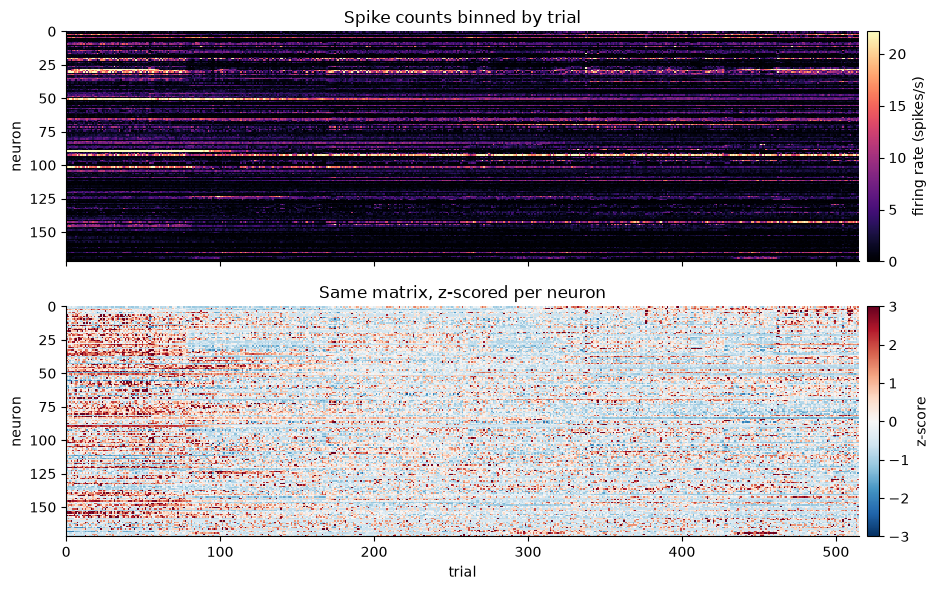

In [29]:
# import the show_matrix helper function
from workshop2_utils import show_matrix

# setup the plotting area
fig, axes = plt.subplots(2, 1, figsize=(9.5, 6), sharex=True)

# plot the raw firing rate matrix on the first subplot
show_matrix(axes[0], fr_dr, 'magma', 0, np.percentile(fr_dr, 99.5),
            'Spike counts binned by trial', 'firing rate (spikes/s)')

# plot the z-scored firing rate matrix on the second subplot
show_matrix(axes[1], frz_dr, 'RdBu_r', -3, 3,
            'Same matrix, z-scored per neuron', 'z-score')
axes[1].set_xlabel('trial')
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Locate a behavioral measurement that we can test for correlations with neural activity

Within this data, we want to locate a **slow behavioral signal** that we can test for spurious correlations with.

The code below explores the NWB file structure to find different types of behavior signals that were recorded.

</div>


In [ ]:
# Explore what behavioral time series are available
print('Processing modules:', list(session.processing.keys()))
for mod_name, mod in session.processing.items():
    print(f'  {mod_name}: {list(mod.data_interfaces.keys())}')
print()
print('Acquisition keys:', list(session.acquisition.keys()))


Processing modules: ['behavior', 'ecephys']
  behavior: ['facemap_front_camera', 'facemap_side_camera', 'running_speed', 'dlc_eye_camera', 'eye_tracking', 'licks', 'lp_front_camera', 'lp_side_camera', 'quiescent_interval_violations', 'rewards']
  ecephys: []

Acquisition keys: ['frametimes_eye_camera', 'frametimes_front_camera', 'frametimes_side_camera', 'manipulator_positions']


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Extract running speed per trial

Running speed is a good real-data analog of the simulated pupil trace that we can explore further. Based on our above exploration, it looks like running speed can be found at `processing["behavior"]["running_speed"]`.

Let's extract the running trace and average the instantaneous speed within each trial window.

</div>


Running speed per trial: mean=42.00, std=10.64


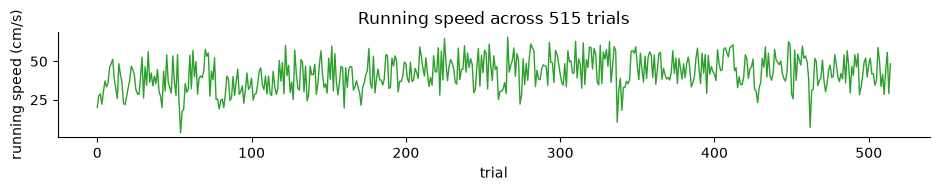

In [12]:
# Retrieve running speed
rs               = session.processing["behavior"]["running_speed"]
running_speed_dr = rs.data[:]
running_times_dr = rs.timestamps[:]

# Average within each trial window
running_trial_dr = np.array([
    np.mean(np.abs(running_speed_dr[(running_times_dr >= ts) &
                                    (running_times_dr <  te)]))
    for ts, te in zip(t_starts, t_stops)
])

running_z_dr = ((running_trial_dr - running_trial_dr.mean())
                / (running_trial_dr.std() + 1e-9))

print(f'Running speed per trial: mean={running_trial_dr.mean():.2f}, std={running_trial_dr.std():.2f}')

fig, ax = plt.subplots(figsize=(9.5, 2))
ax.plot(running_trial_dr, color='tab:green', lw=1.0)
ax.set_xlabel('trial'); ax.set_ylabel('running speed (cm/s)')
ax.set_title(f'Running speed across {n_trials_dr} trials')
plt.tight_layout(); plt.show()

# Part 2 - Neuron Correlation with Running Speed

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## Are MOs neurons correlated with running speed?

We computed the mean running speed within each trial window and z-scored it. We will now correlate the running speed with each neuron's trial-by-trial firing rate using the same analysis pipeline applied to the simulated data in Workshop 2.

In [18]:
# setup code for importing helper functions
import sys, importlib
sys.path.append('utils')
import workshop2_utils
importlib.reload(workshop2_utils) # automatically reloads helper functions if they are changed while kernel is running

# import helper functions
from workshop2_utils import corr_rows, crit_r, hist_by_significance

n = 515 trials  →  any |r| > 0.086 gives p < 0.05
137 / 172 neurons significant (p < 0.05)
Expected by chance: 8.6 / 172
Median |r| = 0.180, max |r| = 0.711


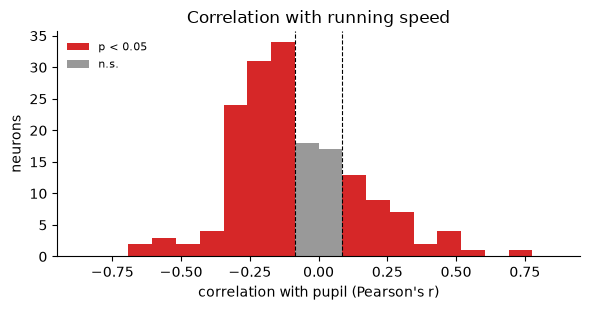

In [24]:
# Compute correlations with running speed using the same pipeline as Part 1
r_dr   = corr_rows(fr_dr, running_trial_dr)
r_crit_dr = crit_r(n_trials_dr)

# Compute parametric p-values
res_dr = [stats.pearsonr(fr_dr[i], running_trial_dr) for i in range(n_neurons_dr)]
p_dr   = np.array([x.pvalue for x in res_dr])
n_sig_dr = np.sum(p_dr < 0.05)

print(f'n = {n_trials_dr} trials  →  any |r| > {r_crit_dr:.3f} gives p < 0.05')
print(f'{n_sig_dr} / {n_neurons_dr} neurons significant (p < 0.05)')
print(f'Expected by chance: {0.05 * n_neurons_dr:.1f} / {n_neurons_dr}')
print(f'Median |r| = {np.median(np.abs(r_dr)):.3f}, max |r| = {np.max(np.abs(r_dr)):.3f}')

_edges_dr = np.arange(0, 0.8 + r_crit_dr, r_crit_dr)
R_BINS_DR = np.concatenate([-_edges_dr[1:][::-1], _edges_dr])

fig, ax = plt.subplots(figsize=(6, 3.2))
hist_by_significance(ax, r_dr, 
    f'Correlation with running speed',
    R_BINS_DR, r_crit_dr)
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: How many neurons appear correlated with running speed?

1. **How many neuron's were found to be significantly correlated with running speed?** Print `n_sig_dr`. 

2. **How does this number compare to the `~5%` you'd expect by chance?**


</div>


In [27]:
# YOUR CODE HERE
print(f'{n_sig_dr}/{n_neurons_dr} significant')
print(f'{0.05*n_neurons_dr:.0f}/{n_neurons_dr} expected by chance')

137/172 significant
9/172 expected by chance


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## Control: circular shift

Let's apply the circular shift control to our neuronal signal to see what result we get. 

In [ ]:
N_SHIFT_DR    = 200
shift_dr      = np.random.default_rng(42).integers(1, n_trials_dr, N_SHIFT_DR)

r_circ_dr = np.array([corr_rows(np.roll(fr_dr, s, axis=1), running_trial_dr)
                       for s in shift_dr])
p_circ_dr     = (np.sum(np.abs(r_circ_dr) >= np.abs(r_dr), axis=0) + 1) / (N_SHIFT_DR + 1)
n_sig_circ_dr = np.sum(p_circ_dr < 0.05)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(r_circ_dr.ravel(), bins=R_BINS_DR, density=True, color='0.6',
             label='circular-shift null')
axes[0].hist(r_dr, bins=R_BINS_DR, density=True, color='tab:blue', alpha=0.6,
             label='real data')
axes[0].set_xlabel("correlation with running speed (Pearson's r)")
axes[0].set_ylabel('density')
axes[0].set_title('Real DR data: circular-shift null vs real correlations')
axes[0].legend(frameon=False, fontsize=8)

axes[1].hist(p_circ_dr, bins=np.linspace(0, 1, 21), color='0.6')
axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[1].set_xlabel('p-value vs circular-shift null')
axes[1].set_ylabel('neurons')
axes[1].set_title(f'Only {n_sig_circ_dr}/{n_neurons_dr} neurons survive the shift test')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f'Parametric p < 0.05:          {n_sig_dr:3d} / {n_neurons_dr}')
print(f'Circular-shift null p < 0.05: {n_sig_circ_dr:3d} / {n_neurons_dr}')


### 14.3 Test 2 (real data): Decoding the Context Block


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

Now we decode the **visual vs auditory context block** using the DR population.
This is exactly analogous to decoding the +1/−1 block variable in our simulation.

We compare:
- **Trial-wise 10-fold CV** — the naive approach
- **Leave-one-block-out CV** — the proper control

</div>


In [ ]:
# Get block labels: visual context = +1, auditory context = -1
# Adjust the column name if needed based on what you found in Checkpoint 7
CONTEXT_COL = 'context_name'    # change this if the column has a different name
if CONTEXT_COL not in trials.columns:
    # Try to find the right column automatically
    for col in trials.columns:
        vals = trials[col].dropna().unique()
        if set(vals) == {'visual', 'auditory'} or set(vals) == {0, 1} or set(vals) == {-1, 1}:
            CONTEXT_COL = col
            print(f'Using context column: {CONTEXT_COL}')
            break

context_raw = trials[CONTEXT_COL].values
# Map to +1 / -1 if needed
if context_raw.dtype == object:
    context_vals = np.where(context_raw == 'visual', 1, -1).astype(float)
else:
    context_vals = context_raw.astype(float)
    if set(np.unique(context_vals[~np.isnan(context_vals)])) == {0.0, 1.0}:
        context_vals = 2 * context_vals - 1   # remap 0/1 → -1/+1

# Drop trials with NaN context
valid = ~np.isnan(context_vals)
X_dr  = fr_dr[:, valid].T                  # (valid_trials, neurons)
y_dr  = context_vals[valid]
idx_dr = np.where(valid)[0]

# Reconstruct block IDs from the context signal
block_ids_dr = np.zeros(len(y_dr), dtype=int)
b = 0
for i in range(1, len(y_dr)):
    if y_dr[i] != y_dr[i - 1]:
        b += 1
    block_ids_dr[i] = b

print(f'{valid.sum()} trials with known context ({len(np.unique(block_ids_dr))} blocks)')
print(f'Context distribution: {np.mean(y_dr==1)*100:.0f}% visual, '
      f'{np.mean(y_dr==-1)*100:.0f}% auditory')


In [ ]:
# Trial-wise 10-fold CV
acc_tw_dr = trialwise_cv(X_dr, y_dr)

# Leave-one-block-out
acc_bo_dr_all = blockout_cv(X_dr, y_dr, block_ids_dr)
acc_bo_dr     = np.mean(acc_bo_dr_all)

print(f'Trial-wise 10-fold CV accuracy:     {acc_tw_dr*100:.1f}%  (chance = 50%)')
print(f'Leave-one-block-out mean accuracy:  {acc_bo_dr*100:.1f}%  (chance = 50%)')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

# Trial-wise
axes[0].bar(['trial-wise CV', 'leave-one-block-out'],
            [acc_tw_dr * 100, acc_bo_dr * 100],
            color=['0.5', 'tab:blue'])
axes[0].axhline(50, color='k', ls='--', lw=1, label='chance')
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('accuracy (%)')
axes[0].set_title('Decoding visual vs auditory context\nfrom real DR data')
axes[0].legend(frameon=False, fontsize=8)

# Block-out per block
blocks_dr = np.unique(block_ids_dr)
axes[1].bar(range(len(blocks_dr)), acc_bo_dr_all * 100,
            color=['tab:blue' if y_dr[block_ids_dr == b][0] > 0 else 'tab:orange'
                   for b in blocks_dr])
axes[1].axhline(np.mean(acc_bo_dr_all) * 100, color='k',
                label=f'mean = {np.mean(acc_bo_dr_all)*100:.0f}%')
axes[1].axhline(50, color='0.3', ls='--', lw=1, label='chance')
axes[1].set_xlabel('held-out block')
axes[1].set_ylabel('accuracy (%)')
axes[1].set_title('Leave-one-block-out: per block\n(blue = visual, orange = auditory)')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: Interpreting the real-data decoding results

Compare the two decoding results:

1. What is the trial-wise CV accuracy? What is the leave-one-block-out accuracy?
   Do they agree?
2. If block-out is *below* chance: does this mean MOs neurons know nothing about
   the context? Or does it mean something more specific about what kind of
   information drives the trial-wise CV performance?
3. If block-out is *above* chance: how strong must the true block coding be?
   (Recall from Section 12: block-out is conservative — it needs a substantial
   real effect to call it.)
4. What would you tell a collaborator who showed you the trial-wise CV result
   alone and concluded "MOs strongly encodes visual vs auditory context"?

</div>


In [ ]:
# ✏️ Your code here
# Hint: print(f'Trial-wise CV:    {acc_tw_dr*100:.1f}%')
print(f'Leave-block-out:  {acc_bo_dr*100:.1f}%')
print(f'Difference:       {(acc_tw_dr - acc_bo_dr)*100:.1f} percentage points')



### 14.4 Summary: Simulated vs Real Data


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## Final Summary

You have now seen the same pitfall in both simulated and real data:

### What the naive analyses found

| Analysis | Simulated (null) | Real DR data |
|----------|-----------------|--------------|
| Parametric pupil/speed correlation | ~79% significant | ? / 100% |
| Trial-wise block decoding | ~81% accuracy | ? % accuracy |

### What the proper controls found

| Control | Simulated (null) | Real DR data |
|---------|-----------------|--------------|
| Circular-shift correlation | ~4% significant | ~5% significant |
| Leave-one-block-out decoding | ~10% accuracy | ? % accuracy |

### Key lessons

1. **Slow fluctuations in neural firing rates are universal.** Any signal that
   also varies slowly (pupil, running speed, block variable) will appear
   correlated with neural activity, even with no causal relationship.

2. **Shuffling trials as a null is not a test of the claim.** It destroys the
   slow structure that generates the artefact, so its null is at chance even
   when the original result is entirely spurious.

3. **The circular shift is the right null for pupil/behavioral correlations.**
   It preserves the slow fluctuation structure and only breaks the alignment.

4. **Leave-one-block-out CV is the right test for block-variable decoding.**
   Trial-wise CV leaks slow fluctuation information across the train/test split.

5. **Effective N can be much less than nominal N.** With a 25 s fluctuation
   timescale and 1 s trials, 511 trials are worth about 21 independent observations.

6. **The good controls are conservative, not blind.** They do find real effects
   when the signal is large enough — they just also keep the false-positive rate
   at the nominal level.

</div>
